# Module 09 — Unsupervised Learning

Supervised learning has a referee: the held-out label. Unsupervised learning
has none, and that makes it *harder*, not easier — because there is nothing to
stop you from shipping a beautiful segmentation of pure noise.

The discipline of this module is therefore mostly negative: how to tell
whether structure you found is real, and how to avoid the three specific traps
(clusters that always appear, t-SNE distances that mean nothing, PCA on
unscaled data) that account for most of the bad unsupervised work in practice.

### Learning objectives

1. State each clustering algorithm's *assumption*, and pick from that.
2. Choose *k* using something better than the elbow.
3. Evaluate a clustering with and without labels, and test whether the
   structure is real at all.
4. Use PCA correctly — and know why t-SNE/UMAP output must never become
   features.
5. Detect anomalies without labels, and know how that compares to a supervised
   model when labels do exist.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

## 1. Every clustering algorithm is an assumption

| Algorithm | Assumes clusters are… | Needs *k*? | Handles noise? | Scales to |
|---|---|---|---|---|
| `KMeans` | spherical, similar size, similar density | **yes** | no — every point is assigned | millions (MiniBatch) |
| `GaussianMixture` | elliptical Gaussians, any orientation | **yes** | soft assignment | ~100k |
| `DBSCAN` | dense regions of any shape, uniform density | no | **yes** — explicit noise label | ~100k |
| `HDBSCAN` | dense regions, **varying** density | no | **yes** | ~100k |
| `AgglomerativeClustering` | nested/hierarchical | yes (or a distance cut) | no | ~20k (O(n²) memory) |
| `SpectralClustering` | connected in a similarity graph | **yes** | no | ~10k |

The choice is a claim about the data. "We used k-means" is a statement that
you believe your segments are round blobs of similar size — which is a strong
claim about customers, and usually a false one.

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


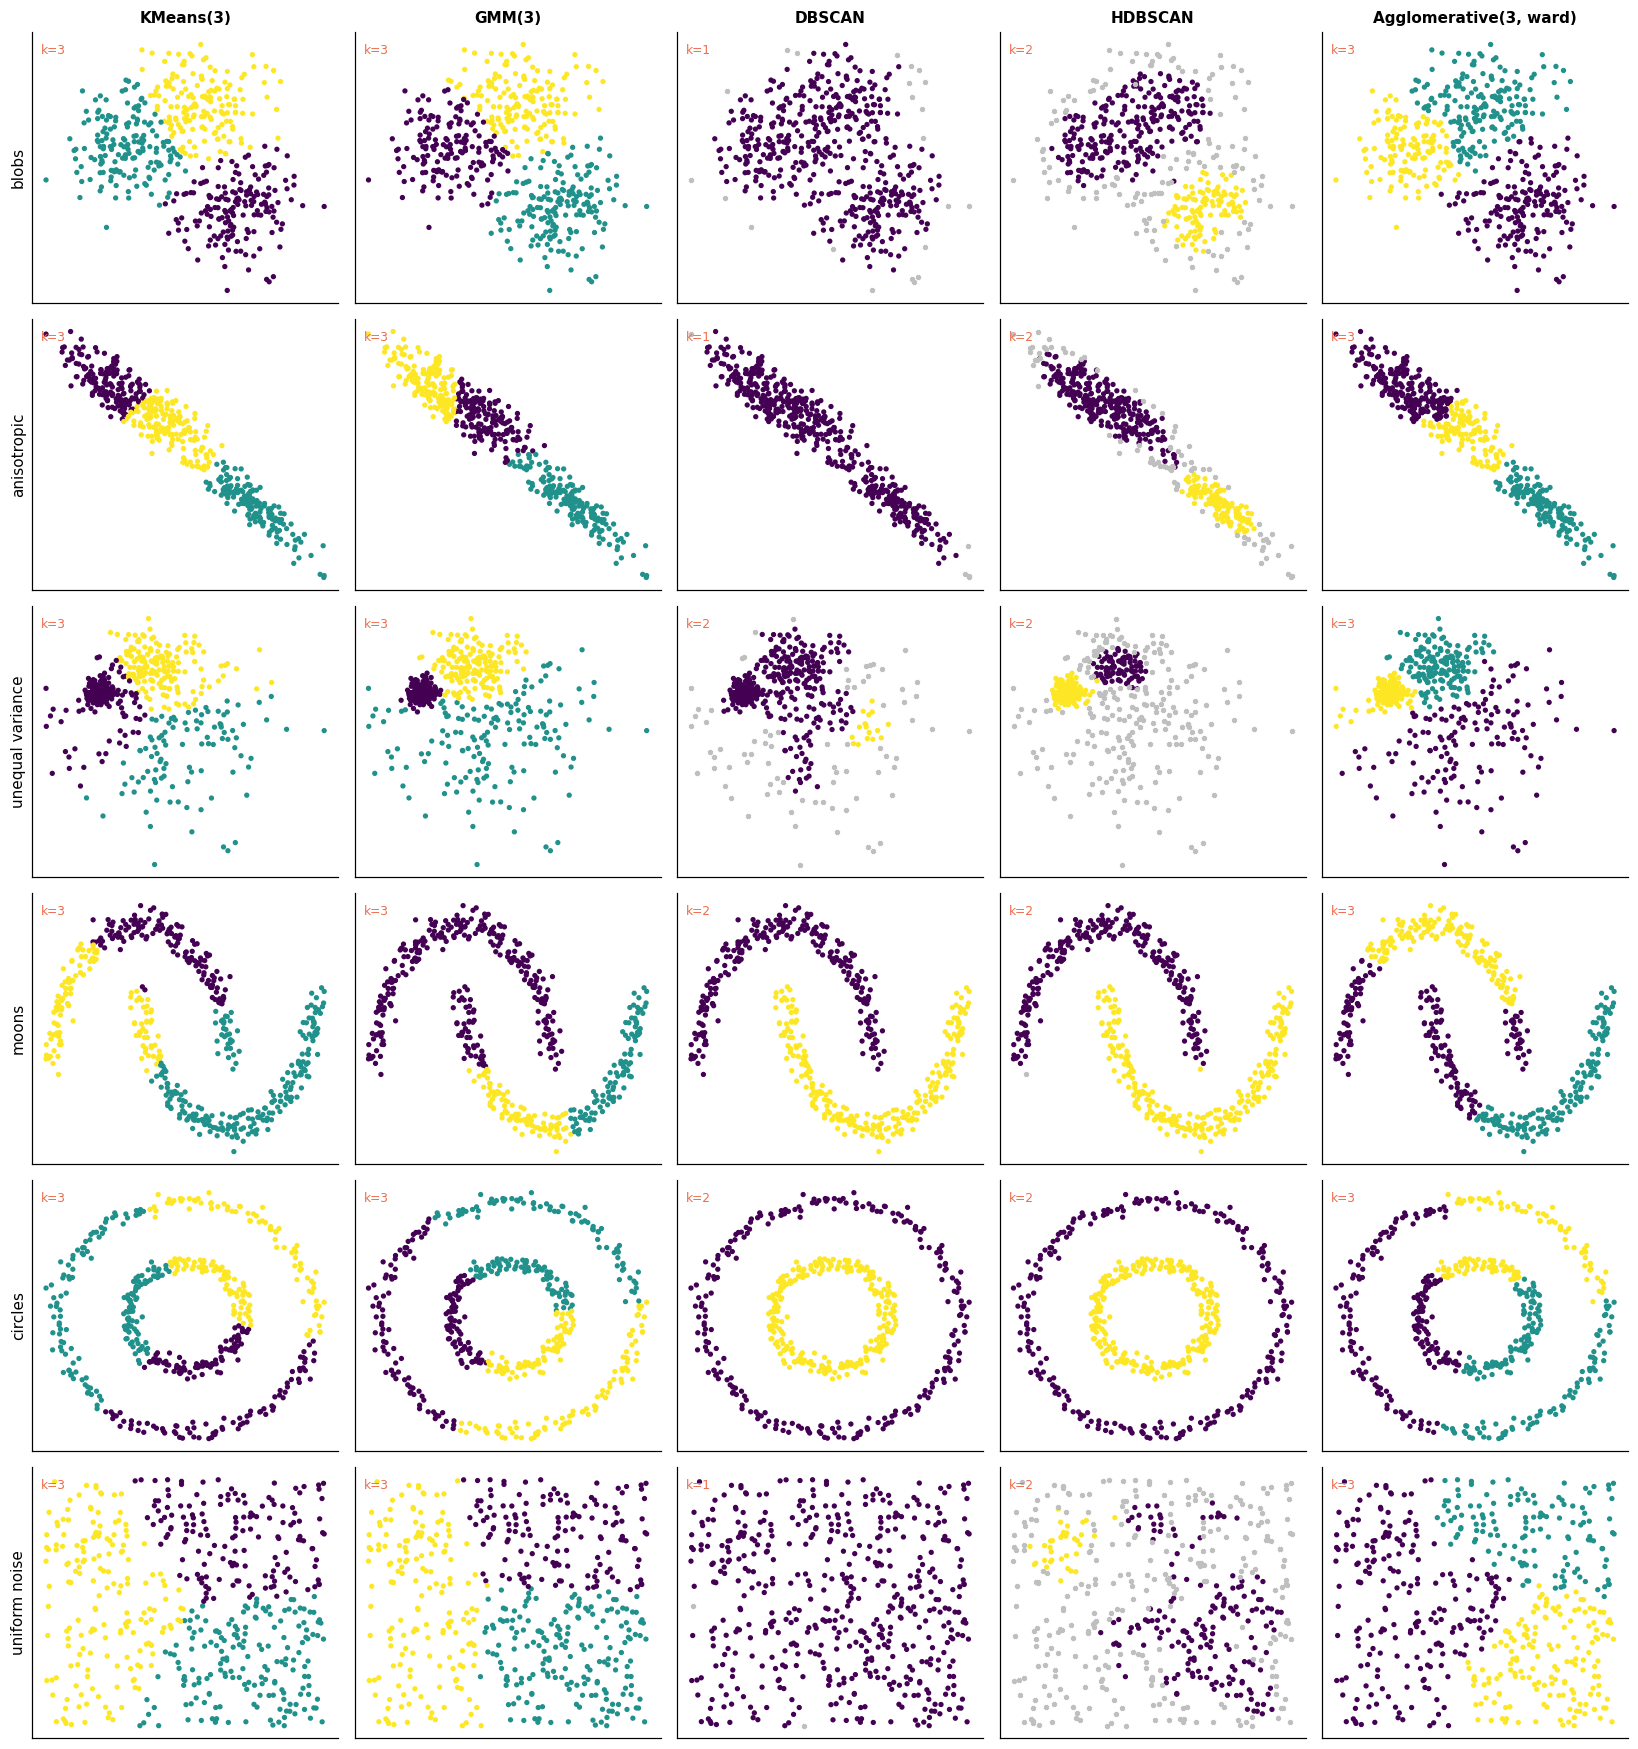

In [2]:
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

n = 500
datasets = {
    "blobs": make_blobs(n_samples=n, centers=3, cluster_std=1.0, random_state=0)[0],
    "anisotropic": make_blobs(n_samples=n, centers=3, random_state=0)[0] @ [[0.6, -0.6], [-0.4, 0.85]],
    "unequal variance": make_blobs(n_samples=n, centers=3, cluster_std=[1.0, 2.6, 0.4], random_state=0)[0],
    "moons": make_moons(n_samples=n, noise=0.06, random_state=0)[0],
    "circles": make_circles(n_samples=n, noise=0.04, factor=0.45, random_state=0)[0],
    "uniform noise": rng.uniform(-3, 3, size=(n, 2)),
}
algos = {
    "KMeans(3)": lambda: KMeans(n_clusters=3, n_init=10, random_state=0),
    "GMM(3)": lambda: GaussianMixture(n_components=3, random_state=0),
    "DBSCAN": lambda: DBSCAN(eps=0.35, min_samples=8),
    "HDBSCAN": lambda: HDBSCAN(min_cluster_size=20),
    "Agglomerative(3, ward)": lambda: AgglomerativeClustering(n_clusters=3),
}

fig, axes = plt.subplots(len(datasets), len(algos), figsize=(15, 16))
for i, (dname, Xd) in enumerate(datasets.items()):
    Xs = StandardScaler().fit_transform(Xd)
    for j, (aname, factory) in enumerate(algos.items()):
        labels = factory().fit_predict(Xs)
        ax = axes[i, j]
        noise = labels == -1
        ax.scatter(Xs[~noise, 0], Xs[~noise, 1], c=labels[~noise], s=6, cmap="viridis")
        ax.scatter(Xs[noise, 0], Xs[noise, 1], c="0.75", s=6, marker="x")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if i == 0:
            ax.set_title(aname, fontsize=10)
        if j == 0:
            ax.set_ylabel(dname, fontsize=10)
        k = len(set(labels)) - (1 if -1 in labels else 0)
        ax.text(0.03, 0.92, f"k={k}", transform=ax.transAxes, fontsize=8, color="#ee6c4d")
plt.tight_layout()

**Look at the bottom row.** It is uniform random noise — there are no clusters,
by construction. `KMeans`, `GMM` and `Agglomerative` all confidently return
three of them, because they were told to. `DBSCAN` and `HDBSCAN` mostly say
"noise", which is the correct answer.

> 💼 **Consulting lens.** This is the single most useful diagnostic in
> segmentation work: **run your pipeline on shuffled or simulated data with no
> structure, and see what it produces.** If the noise segmentation looks about
> as convincing as the real one — comparable silhouette, similar-sized
> segments, a plausible-sounding story per segment — you have learned
> something important before the steering committee does.

## 2. Choosing *k*

Four methods, in increasing order of how much I trust them.

,inertia,silhouette,calinski_harabasz,davies_bouldin,gmm_bic
k,,,,,
2,754.942,0.585,1243.091,0.798,2986.271
3,199.768,0.758,3592.691,0.342,2026.848
4,57.453,0.781,9058.467,0.311,1523.883
5,51.832,0.658,7546.610,0.640,1563.381
6,46.333,0.561,6768.751,0.837,1597.125
7,40.761,0.474,6424.207,0.962,1628.680
8,35.519,0.342,6331.123,1.115,1649.506
9,32.469,0.349,6063.353,1.033,1687.757
10,29.141,0.357,6009.769,0.975,1720.277


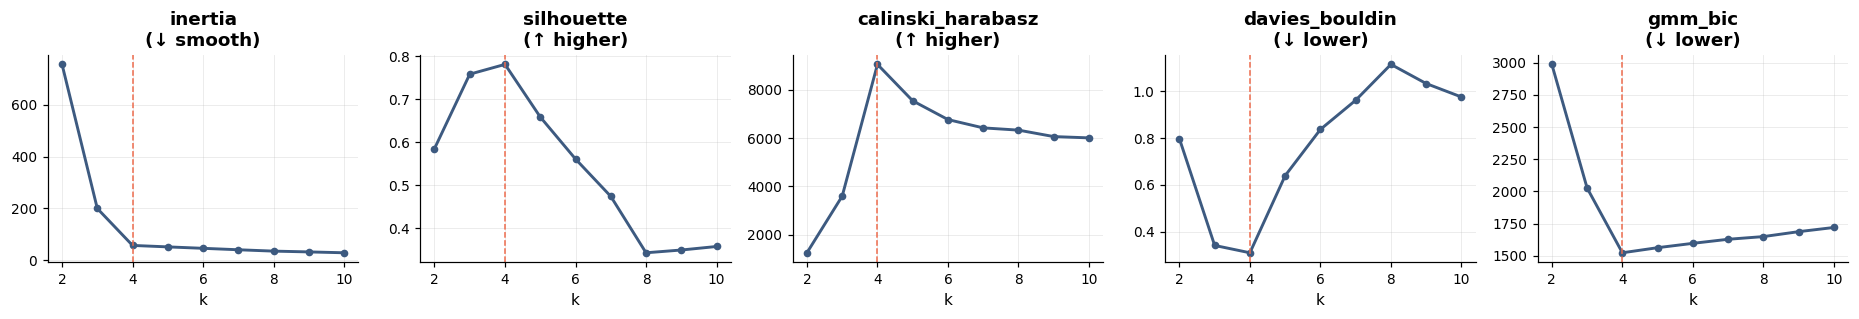

In [3]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

Xk, y_true_k = make_blobs(n_samples=900, centers=4, cluster_std=1.1, random_state=7)
Xk = StandardScaler().fit_transform(Xk)

ks = range(2, 11)
diag = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xk)
    gm = GaussianMixture(n_components=k, random_state=0).fit(Xk)
    diag.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Xk, km.labels_),
        "calinski_harabasz": calinski_harabasz_score(Xk, km.labels_),
        "davies_bouldin": davies_bouldin_score(Xk, km.labels_),
        "gmm_bic": gm.bic(Xk),
    })
diag = pd.DataFrame(diag).set_index("k")

fig, axes = plt.subplots(1, 5, figsize=(17, 3))
for ax, col, better in zip(axes, diag.columns, ["↓ smooth", "↑ higher", "↑ higher", "↓ lower", "↓ lower"]):
    ax.plot(diag.index, diag[col], marker="o", ms=4)
    ax.axvline(4, ls="--", color="#ee6c4d", lw=1)
    ax.set(title=f"{col}\n({better})", xlabel="k")
plt.tight_layout()
diag.round(3)

- **Inertia / the elbow** — always decreases with *k*, so there is no optimum,
  only a subjective kink. It is the most-taught and least-reliable method.
- **Silhouette** — how much closer each point is to its own cluster than to
  the next nearest, in [−1, 1]. Has a genuine maximum. Biased towards convex,
  well-separated clusters, so it flatters k-means.
- **Calinski–Harabasz** — between/within variance ratio. Fast, same convexity
  bias.
- **Davies–Bouldin** — average similarity of each cluster to its most similar
  one; lower is better.
- **BIC on a Gaussian mixture** — the only one on this list with a
  *statistical* basis. It has a real minimum because it penalises parameters.
  When a probabilistic model is defensible, this is the one to use.

The honest summary: these indices agree when the structure is obvious and
disagree when it is not — which is exactly when you needed them. Treat them as
evidence, not as an answer, and always look at the per-point silhouette
distribution rather than the mean.

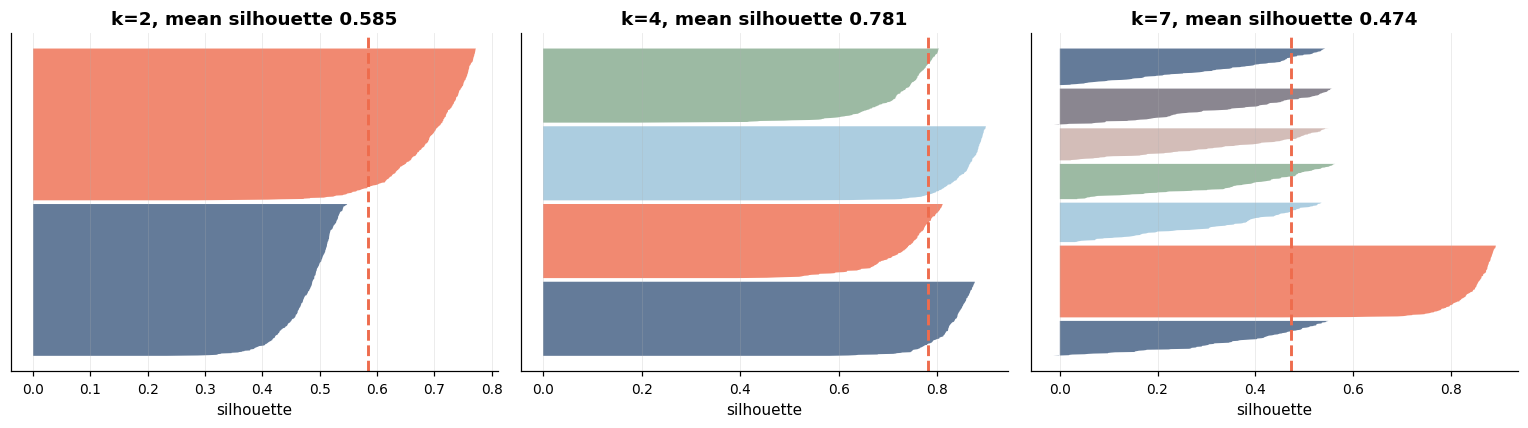

In [4]:
# The silhouette plot: the mean hides everything interesting.
from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, k in zip(axes, [2, 4, 7]):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xk)
    sv = silhouette_samples(Xk, labels)
    lower = 10
    for c in range(k):
        vals = np.sort(sv[labels == c])
        ax.fill_betweenx(np.arange(lower, lower + len(vals)), 0, vals, alpha=0.8)
        lower += len(vals) + 10
    ax.axvline(sv.mean(), color="#ee6c4d", ls="--")
    ax.set(title=f"k={k}, mean silhouette {sv.mean():.3f}", xlabel="silhouette", yticks=[])
plt.tight_layout()

A cluster whose silhouette values are mostly below the mean line is a cluster
the algorithm invented to satisfy your *k*. That is visible here and invisible
in the summary statistic.

## 3. Evaluating with labels, when you happen to have them

Sometimes you have ground truth and want to know whether an unsupervised
method recovers it. Use the label-aware metrics, and use the *adjusted* ones —
the unadjusted versions reward you for guessing more clusters.

In [5]:
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    rand_score,
    v_measure_score,
)

rows = []
for k in [2, 4, 8, 20]:
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xk)
    rows.append({
        "k": k,
        "rand (unadjusted)": rand_score(y_true_k, labels),
        "adjusted_rand": adjusted_rand_score(y_true_k, labels),
        "adjusted_mutual_info": adjusted_mutual_info_score(y_true_k, labels),
        "homogeneity": homogeneity_score(y_true_k, labels),
        "completeness": completeness_score(y_true_k, labels),
        "v_measure": v_measure_score(y_true_k, labels),
    })
pd.DataFrame(rows).set_index("k").round(4)

,rand (unadjusted),adjusted_rand,adjusted_mutual_info,homogeneity,completeness,v_measure
k,,,,,,
2,0.7497,0.4992,0.6661,0.5,1.0000,0.6667
4,1.0000,1.0000,1.0000,1.0,1.0000,1.0000
8,0.8756,0.6011,0.7994,1.0,0.6677,0.8007
20,0.8028,0.2835,0.6319,1.0,0.4677,0.6374


Watch `homogeneity` climb towards 1.0 at k=20 while `adjusted_rand` collapses.
Homogeneity only asks "is each cluster pure?" — and twenty tiny clusters are
trivially pure. `completeness` is its counterweight, and the adjusted indices
correct for chance agreement. **Report an adjusted index, or report the pair.**

## 4. A real segmentation, done carefully

Segmenting the credit book. The workflow that matters is: scale → reduce (if
needed) → cluster → **validate against noise** → profile.

In [6]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer

credit = load_credit_risk()
seg_cols = ["age", "annual_income", "loan_amount", "interest_rate", "debt_to_income",
            "credit_score", "n_open_accounts", "employment_years", "home_ownership", "purpose", "employment_type"]

seg_prep = ColumnTransformer([
    # QuantileTransformer rather than StandardScaler: incomes are log-normal and
    # k-means is a squared-distance method, so a handful of high earners would
    # otherwise define an entire cluster on their own.
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("qt", QuantileTransformer(output_distribution="normal", random_state=0))]),
     make_column_selector(dtype_include=np.number)),
    ("cat", OneHotEncoder(sparse_output=False, min_frequency=100), make_column_selector(dtype_include=["object", "string"])),
])
Z = seg_prep.fit_transform(credit[seg_cols])
print("segmentation matrix:", Z.shape)

segmentation matrix: (12000, 23)


,silhouette_real,silhouette_shuffled
k,,
2,0.1363,0.0652
3,0.1240,0.0604
4,0.1044,0.0576
5,0.0905,0.0562
6,0.0853,0.0560
7,0.0847,0.0589
8,0.0887,0.0643


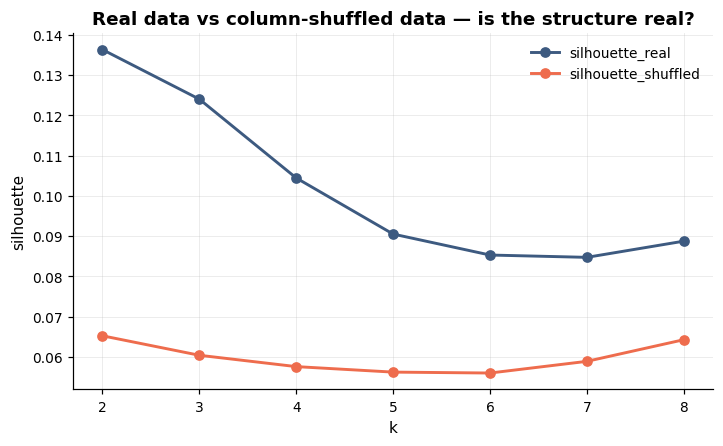

In [7]:
# Choose k -- and simultaneously run the SAME pipeline on structure-free data.
Z_null = np.column_stack([rng.permutation(col) for col in Z.T])   # shuffle each column independently

comp = []
for k in range(2, 9):
    real = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    null = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z_null)
    comp.append({"k": k,
                 "silhouette_real": silhouette_score(Z, real.labels_, sample_size=4000, random_state=0),
                 "silhouette_shuffled": silhouette_score(Z_null, null.labels_, sample_size=4000, random_state=0)})
comp = pd.DataFrame(comp).set_index("k")
ax = comp.plot(marker="o")
ax.set(ylabel="silhouette", title="Real data vs column-shuffled data — is the structure real?")
comp.round(4)

Shuffling each column independently destroys all *joint* structure while
preserving every marginal distribution. If the real data's silhouette is not
clearly above the shuffled data's, your clusters are an artefact of the
geometry, not a finding about customers.

This is a five-line test and it should be in every segmentation deliverable.

In [8]:
# Profile the segments in the ORIGINAL units. A segmentation nobody can describe
# is a segmentation nobody will use.
K = 4
seg_labels = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(Z)
profile = credit.assign(segment=seg_labels).groupby("segment").agg(
    n=("default", "size"),
    default_rate=("default", "mean"),
    median_income=("annual_income", "median"),
    median_score=("credit_score", "median"),
    median_dti=("debt_to_income", "median"),
    median_rate=("interest_rate", "median"),
    pct_mortgage=("home_ownership", lambda s: (s == "mortgage").mean()),
).round(3)
profile

,n,default_rate,median_income,median_score,median_dti,median_rate,pct_mortgage
segment,,,,,,,
0,2516,0.128,17700.0,622.0,0.339,15.465,0.446
1,3341,0.272,29200.0,599.0,0.528,16.480,0.442
2,2622,0.065,52800.0,673.0,0.355,14.710,0.444
3,3521,0.055,28500.0,671.0,0.234,14.270,0.431


Two things to check before anyone presents this:

1. **Are the segments different in ways that matter?** If `default_rate` is
   similar across all of them, the segmentation is not risk-relevant, whatever
   else it separates.
2. **Would a supervised model have found this faster?** If the goal is to
   predict default, a supervised model does it directly and better. Clustering
   earns its place when the goal is *communication and action* — different
   treatment strategies per segment — not prediction.

## 5. Dimensionality reduction

### PCA: rotate to the directions of maximum variance

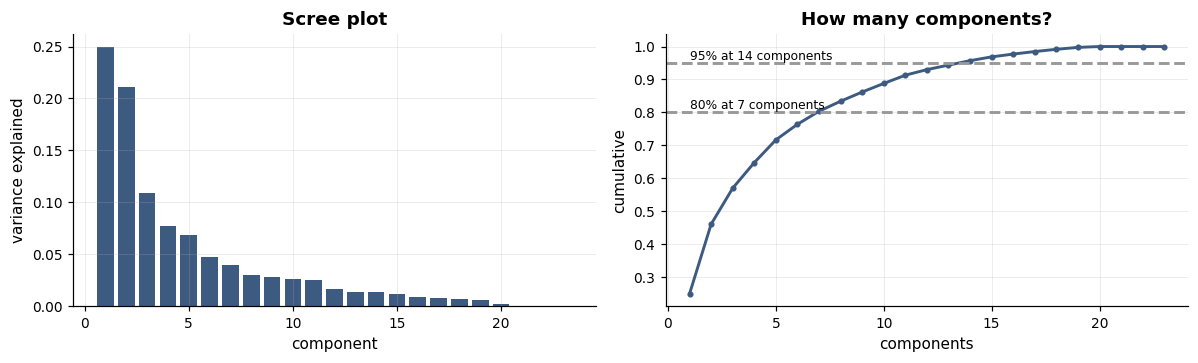

In [9]:
from sklearn.decomposition import PCA

pca = PCA().fit(Z)
cum = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color="#3d5a80")
axes[0].set(xlabel="component", ylabel="variance explained", title="Scree plot")
axes[1].plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
for lvl in [0.8, 0.95]:
    axes[1].axhline(lvl, ls="--", color="0.6")
    axes[1].text(1, lvl + 0.01, f"{lvl:.0%} at {np.argmax(cum >= lvl) + 1} components", fontsize=8)
axes[1].set(xlabel="components", ylabel="cumulative", title="How many components?")
plt.tight_layout()

In [10]:
# `n_components` accepts a float: "keep enough components for this much variance".
for target in [0.80, 0.95, 0.99]:
    p = PCA(n_components=target).fit(Z)
    print(f"{target:.0%} of variance -> {p.n_components_:2d} components (from {Z.shape[1]})")

# `n_components="mle"` estimates the dimensionality from the data.
print(f"\nMLE estimate            -> {PCA(n_components='mle').fit(Z).n_components_} components")

80% of variance ->  7 components (from 23)
95% of variance -> 14 components (from 23)
99% of variance -> 18 components (from 23)

MLE estimate            -> 20 components


**PCA requires scaling.** It maximises variance, so a feature measured in
pounds will dominate one measured in years no matter how uninformative it is.
Forgetting this is the most common PCA error.

In [11]:
from sklearn.datasets import load_wine

Xw = load_wine(as_frame=True).data
unscaled = PCA(n_components=2).fit(Xw)
scaled = PCA(n_components=2).fit(StandardScaler().fit_transform(Xw))

loadings = pd.DataFrame({
    "unscaled |PC1 loading|": np.abs(unscaled.components_[0]),
    "scaled |PC1 loading|": np.abs(scaled.components_[0]),
}, index=Xw.columns).sort_values("unscaled |PC1 loading|", ascending=False).round(3)
print("Variance of each feature (raw):")
print(Xw.var().sort_values(ascending=False).head(3).round(1).to_string())
loadings.head(6)

Variance of each feature (raw):
proline              99166.7
magnesium              204.0
alcalinity_of_ash       11.2


,unscaled |PC1 loading|,scaled |PC1 loading|
proline,1.000,0.287
magnesium,0.018,0.142
alcalinity_of_ash,0.005,0.239
color_intensity,0.002,0.089
alcohol,0.002,0.144
flavanoids,0.002,0.423


Unscaled, PC1 is essentially `proline` — the feature with the largest raw
variance, which is an artefact of its unit. Scaled, PC1 is a blend of many
features and actually means something.

### The rest of the decomposition family

| Method | Constraint | Use for |
|---|---|---|
| `PCA` | orthogonal, maximum variance | general-purpose; needs dense input |
| `TruncatedSVD` | same, but no centering | **sparse** data (text, one-hot); "LSA" |
| `NMF` | all components non-negative | parts-based decomposition; topics, spectra |
| `KernelPCA` | PCA in a kernel-implied space | non-linear structure; `inverse_transform` is approximate |
| `FastICA` | statistically independent components | source separation, not variance |
| `SparsePCA` | sparse loadings | when you need each component to name a few features |

`NMF`'s non-negativity is why it produces interpretable "parts": it cannot
cancel one feature against another, so components tend to be additive pieces
rather than contrasts.

### t-SNE and UMAP: visualisation *only*

Three rules, and violating any of them produces confidently wrong conclusions:

1. **Never use the output as features.** t-SNE has no `transform` method — it
   cannot embed new points, by design. That alone tells you it is not a
   preprocessing step.
2. **Distances between clusters are meaningless.** t-SNE preserves local
   neighbourhoods and explicitly discards global structure. Two blobs far apart
   in the plot may be adjacent in reality.
3. **Cluster sizes are meaningless.** The algorithm expands sparse regions and
   compresses dense ones.

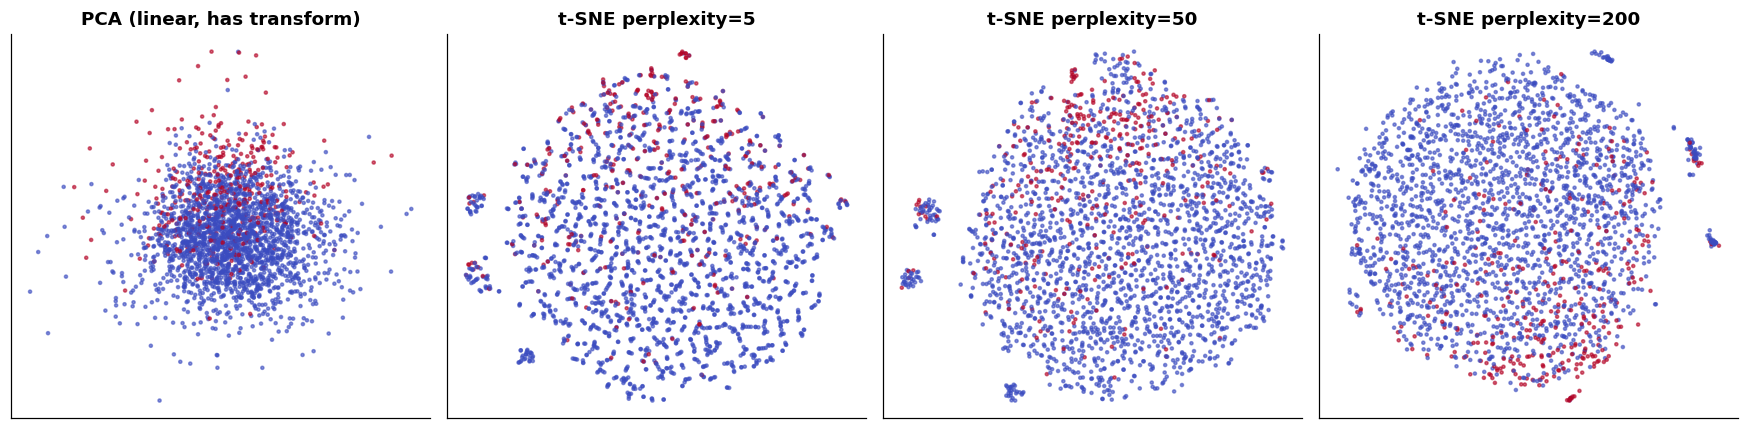

In [12]:
from sklearn.manifold import MDS, TSNE

sample = rng.choice(len(Z), 2500, replace=False)
Z_s = Z[sample]
y_s = credit["default"].to_numpy()[sample]

emb = {
    "PCA (linear, has transform)": PCA(n_components=2, random_state=0).fit_transform(Z_s),
    "t-SNE perplexity=5": TSNE(n_components=2, perplexity=5, random_state=0, init="pca").fit_transform(Z_s),
    "t-SNE perplexity=50": TSNE(n_components=2, perplexity=50, random_state=0, init="pca").fit_transform(Z_s),
    "t-SNE perplexity=200": TSNE(n_components=2, perplexity=200, random_state=0, init="pca").fit_transform(Z_s),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, E) in zip(axes, emb.items()):
    ax.scatter(E[:, 0], E[:, 1], c=y_s, s=4, cmap="coolwarm", alpha=0.6)
    ax.set(title=name, xticks=[], yticks=[])
    ax.grid(False)
plt.tight_layout()

The same data, four pictures, three of them from the *same algorithm* with one
parameter changed. Any narrative you build from one of these panels is a
narrative about `perplexity`.

The proof that t-SNE is not a feature extractor:

In [13]:
tsne = TSNE(n_components=2, random_state=0)
print("TSNE has transform():", hasattr(tsne, "transform"))
print("PCA  has transform():", hasattr(PCA(), "transform"))
print("\nSo t-SNE cannot be a Pipeline step before a classifier -- there is no way")
print("to embed a new applicant at scoring time without refitting on them,")
print("which is leakage even if it were possible.")

TSNE has transform(): False
PCA  has transform(): True

So t-SNE cannot be a Pipeline step before a classifier -- there is no way
to embed a new applicant at scoring time without refitting on them,
which is leakage even if it were possible.


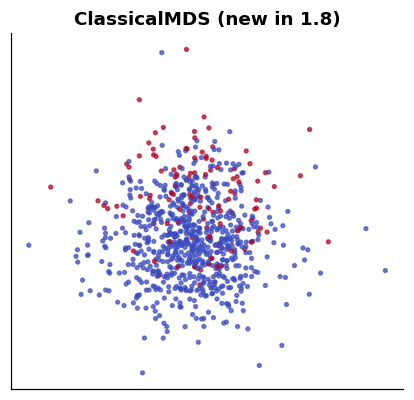

In [14]:
# New in sklearn 1.8: ClassicalMDS (principal coordinates analysis) -- an exact
# eigendecomposition rather than the iterative stress majorisation of MDS.
from sklearn.manifold import ClassicalMDS

cmds = ClassicalMDS(n_components=2).fit_transform(Z_s[:800])
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(cmds[:, 0], cmds[:, 1], c=y_s[:800], s=6, cmap="coolwarm", alpha=0.7)
ax.set(title="ClassicalMDS (new in 1.8)", xticks=[], yticks=[])
ax.grid(False)

## 6. Anomaly detection

Four estimators, three quite different theories of what "anomalous" means.

| Estimator | Theory | Notes |
|---|---|---|
| `IsolationForest` | anomalies are easy to isolate with random splits | fast, scales well, **the default choice** |
| `LocalOutlierFactor` | anomalies have lower local density than their neighbours | catches *local* anomalies; `novelty=False` by default |
| `OneClassSVM` | anomalies fall outside a learned boundary | O(n²)–O(n³); use `SGDOneClassSVM` at scale |
| `EllipticEnvelope` | data is one Gaussian; anomalies are far in Mahalanobis distance | strong assumption, fast, good when it holds |

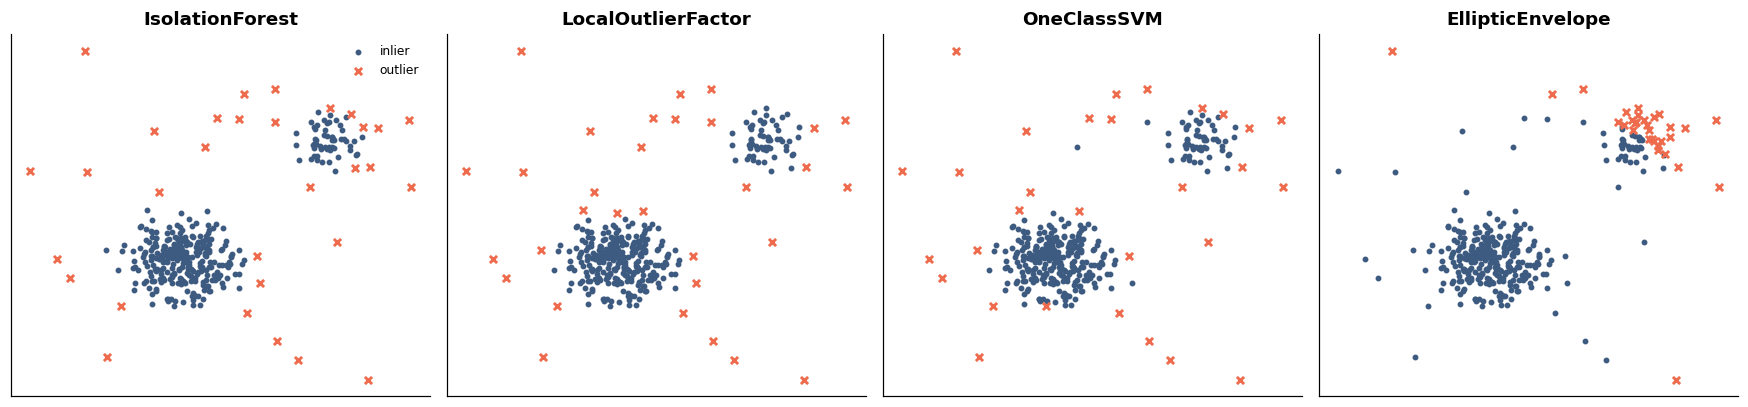

In [15]:
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

Xa = np.vstack([rng.normal(0, 0.6, (300, 2)), rng.normal([3.5, 3.5], 0.4, (60, 2)), rng.uniform(-4, 6, (25, 2))])

detectors = {
    "IsolationForest": IsolationForest(contamination=0.08, random_state=0),
    "LocalOutlierFactor": LocalOutlierFactor(contamination=0.08),
    "OneClassSVM": OneClassSVM(nu=0.08, gamma="scale"),
    "EllipticEnvelope": EllipticEnvelope(contamination=0.08, random_state=0),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (name, det) in zip(axes, detectors.items()):
    pred = det.fit_predict(Xa)
    ax.scatter(Xa[pred == 1, 0], Xa[pred == 1, 1], s=8, color="#3d5a80", label="inlier")
    ax.scatter(Xa[pred == -1, 0], Xa[pred == -1, 1], s=22, color="#ee6c4d", marker="x", label="outlier")
    ax.set(title=name, xticks=[], yticks=[]); ax.grid(False)
axes[0].legend(fontsize=8)
plt.tight_layout()

`EllipticEnvelope` flags the entire second blob, because it assumes one
Gaussian and the blob is far from that Gaussian's centre. Whether that is
right depends entirely on whether "a second population" counts as anomalous in
your problem — which is a business question, not a statistical one.

### `novelty=True`: the distinction that catches people out

`LocalOutlierFactor` has two incompatible modes:

- `novelty=False` (default) — an **outlier detector**. Only `fit_predict`;
  it labels the training data. No `predict` on new data.
- `novelty=True` — a **novelty detector**. Fit on clean data, then `predict`
  new points. `fit_predict` is unavailable.

In [16]:
lof_out = LocalOutlierFactor(n_neighbors=20)
print("novelty=False -> has predict:", hasattr(lof_out, "predict"))
lof_nov = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Xa[:300])
print("novelty=True  -> has predict:", hasattr(lof_nov, "predict"),
      "| new points flagged:", int((lof_nov.predict(Xa[300:]) == -1).sum()), "of", len(Xa) - 300)

novelty=False -> has predict: False
novelty=True  -> has predict: True | new points flagged: 84 of 85


### Unsupervised anomaly detection vs a supervised model

The fraud data has labels, so we can ask the question that unsupervised work
usually cannot: **how much do the labels buy you?**

In [17]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

fraud = load_card_fraud()
fX = fraud.drop(columns=["is_fraud", "timestamp", "card_id"])
for c in fX.select_dtypes(include=["object", "string"]).columns:
    fX[c] = fX[c].astype("category")
fy = fraud["is_fraud"]

f_num = pd.get_dummies(fX, drop_first=True).astype(float)
Xtr, Xte, ytr, yte = train_test_split(f_num, fy, test_size=0.3, stratify=fy, random_state=0)

iso = IsolationForest(contamination=0.01, random_state=0, n_estimators=300).fit(Xtr)
iso_scores = -iso.score_samples(Xte)                     # higher = more anomalous

from sklearn.ensemble import HistGradientBoostingClassifier

sup = HistGradientBoostingClassifier(random_state=0, max_iter=250).fit(Xtr, ytr)
sup_scores = sup.predict_proba(Xte)[:, 1]

pd.DataFrame([
    {"approach": "IsolationForest (no labels)", "roc_auc": roc_auc_score(yte, iso_scores), "avg_precision": average_precision_score(yte, iso_scores)},
    {"approach": "HistGradientBoosting (labels)", "roc_auc": roc_auc_score(yte, sup_scores), "avg_precision": average_precision_score(yte, sup_scores)},
    {"approach": "random baseline", "roc_auc": 0.5, "avg_precision": yte.mean()},
]).set_index("approach").round(4)

,roc_auc,avg_precision
approach,,
IsolationForest (no labels),0.7825,0.0683
HistGradientBoosting (labels),0.8262,0.0771
random baseline,0.5000,0.0069


**The gap is much smaller than you would expect.** The supervised model has
thousands of labels and beats the label-free detector by about 0.04 ROC AUC
and 0.01 average precision. That is a genuine win, but it is not the
order-of-magnitude difference the effort ratio would suggest.

The reason is specific to this problem and worth naming: card fraud largely
*is* anomalousness. The generating process makes fraudulent transactions
unusual in amount, entry mode, device age and geography — so "far from the
bulk of the data" and "fraudulent" substantially coincide. On a problem where
the positive class is not intrinsically unusual — credit default, churn — the
same comparison would be brutal, and `IsolationForest` would sit near 0.5.
**Run this comparison before assuming either answer.**

The same comparison on the credit book, where "unusual applicant" and "will
default" are quite different things:

In [18]:
credit_num = pd.get_dummies(
    credit.drop(columns=["default", "application_id", "collections_flag", "application_month"]),
    drop_first=True,
).astype(float).fillna(-1)
ctr, cte, cytr, cyte = train_test_split(credit_num, credit["default"], test_size=0.3,
                                        stratify=credit["default"], random_state=0)
iso_credit = IsolationForest(random_state=0, n_estimators=200).fit(ctr)
print(f"credit default — IsolationForest ROC AUC : {roc_auc_score(cyte, -iso_credit.score_samples(cte)):.4f}")
print(f"credit default — supervised (Module 08)  : ~0.78")
print("\nNear-useless. Unusual applicants are not the ones who default.")

credit default — IsolationForest ROC AUC : 0.5637
credit default — supervised (Module 08)  : ~0.78

Near-useless. Unusual applicants are not the ones who default.


The value of the unsupervised detector is elsewhere:

- **Cold start.** No labels exist yet, and it will take months of investigation
  to build them.
- **Novel attack patterns.** A supervised model learns the fraud it has seen.
  An anomaly detector flags things that are simply unusual, which is how you
  catch a pattern that has no historical examples.
- **A second opinion.** Running both and reviewing the disagreements is a
  genuinely useful triage strategy.

> 💼 **Consulting lens.** When a client proposes unsupervised anomaly detection
> for a problem where labels exist, the question is not "will it work" — it is
> "why are we not using the labels?" Usually the honest answer is that the
> labels are expensive, delayed, or incomplete, and *that* is the problem worth
> solving.

---
## Exercises

### Exercise 9.1 — Implement k-means from scratch

Write Lloyd's algorithm: initialise centroids, assign, update, repeat. Then:

1. Match `sklearn.cluster.KMeans` inertia on `make_blobs` given the same
   initial centroids.
2. Implement **k-means++** initialisation and show that it reduces the variance
   of final inertia across 50 random restarts, compared to uniform random init.
3. Explain why `n_init=10` is the default, and construct a dataset where
   `n_init=1` reliably finds a bad local optimum.

In [19]:
# Your code here.

### Exercise 9.2 — A null model for segmentation

Write `is_this_real(X, cluster_fn, n_null=25)` that:

1. Clusters the real data and records silhouette, Calinski–Harabasz and
   Davies–Bouldin.
2. Builds `n_null` null datasets by independently permuting each column,
   clusters each, and records the same statistics.
3. Returns an empirical p-value per statistic, plus a plot of the null
   distribution with the observed value marked.

Run it on the credit segmentation for k = 2…8 and on `make_blobs`. State the k
you would defend, and the evidence.

In [20]:
# Your code here.

### Exercise 9.3 — Mixed-type clustering

k-means on one-hot-encoded categoricals is questionable: Euclidean distance
between dummy columns is not a meaningful dissimilarity. Compare four
approaches on the credit data:

1. One-hot + k-means (the naive baseline).
2. Gower distance + `AgglomerativeClustering(metric="precomputed")`.
3. `PCA`/`FAMD`-style reduction first, then k-means.
4. k-prototypes (implement a simple version, or argue why you would not).

Compare on silhouette (using the appropriate distance in each case), stability
under bootstrap resampling, and — most importantly — how different the
resulting segment *profiles* are. Which would you present?

In [21]:
# Your code here.

### Exercise 9.4 — t-SNE is not a feature extractor

Demonstrate the failure concretely:

1. Fit t-SNE on the *full* credit dataset, use the 2-D embedding as features,
   and cross-validate a classifier. Report the (impressive, wrong) score.
2. Explain precisely which step leaked.
3. Do the same with PCA, correctly inside a pipeline, and report the honest
   score.
4. Finally, try UMAP (`pip install umap-learn`), which *does* have a
   `transform`. Is using it as a feature step legitimate? Argue both sides,
   then commit to a position.

In [22]:
# Your code here.

### Exercise 9.5 — An anomaly-detection triage system

Build a fraud triage system that combines the supervised model and
`IsolationForest`:

- Queue A: high supervised score (known patterns).
- Queue B: low supervised score but high anomaly score (possible novel
  patterns).

Size each queue to a fixed daily analyst capacity. Measure the precision of
each queue, the incremental recall Queue B provides over Queue A alone, and
whether the frauds Queue B catches are qualitatively different (compare their
feature distributions). Recommend a capacity split, with reasoning.

In [23]:
# Your code here.

---
## Takeaways

- **Every clustering algorithm encodes an assumption.** Choosing k-means is
  claiming your segments are round blobs of similar size.
- **Clustering always returns clusters.** Run your pipeline on shuffled data;
  if the null looks as good as the real thing, you have no finding.
- The elbow is the weakest way to choose *k*. Prefer silhouette *distributions*
  (not the mean), and BIC when a probabilistic model is defensible.
- Use **adjusted** label-aware indices; homogeneity alone rewards you for
  splitting more finely.
- PCA requires scaling, and `n_components` accepts a variance fraction.
- **t-SNE and UMAP are for pictures.** t-SNE has no `transform`; inter-cluster
  distances and cluster sizes in the plot mean nothing.
- Unsupervised anomaly detection earns its place at cold start, for novel
  patterns, and as a second opinion — not as a substitute for labels you have.

**Next:** Module 10 — text features, and the bridge from `TfidfVectorizer` to
the embedding-based workflows that surround modern AI systems.